# Bimodal Attention Network
1. Arousal-Valence Directed Data Augmentation
2. Multi-Head Attention Fusion
3. Regularisation via Sentiment Masking

* This experiment is conducted to test which technique apply to this enhanced framework is the most effective in contributing the improvement of metrics, compared to hybrid CNN-LSTM architecture. This experiment conducted with fixed epoch without early stopping applied.

# Setup and Configuration

In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tf_keras import callbacks
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Import advanced functions
from ban_functions import (
    Config, 
    prepare_datasets, 
    prep_inputs, 
    build_attention_model, 
    run_evaluation
)

# 1. SETUP & CONFIGURATION
TARGET_CLASSES = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']
EPOCHS = 30
BATCH_SIZE = Config.BATCH_SIZE

# Dictionary to store results
ablation_results = {}

# Helper function to train and evaluate a specific configuration
def run_ablation_experiment(name, use_aug, use_mask, use_attention):
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {name}")
    print(f" - Augmentation: {use_aug}")
    print(f" - Sentiment Masking: {use_mask}")
    print(f" - Attention Fusion: {use_attention}")
    print(f"{'='*60}")

    # Step A: Data Preparation (Handles Augmentation & Masking)
    original_mask_rate = Config.SENTIMENT_MASK_RATE
    Config.SENTIMENT_MASK_RATE = 0.60 if use_mask else 0.0
    
    data = prepare_datasets(TARGET_CLASSES, augment=use_aug)
    
    Config.SENTIMENT_MASK_RATE = original_mask_rate

    X_train = prep_inputs(data['X_m_train'], data['X_s_train'], data['sent_train_enc'])
    X_dev = prep_inputs(data['X_m_dev'], data['X_s_dev'], data['sent_dev_enc'])
    X_test = prep_inputs(data['X_m_test'], data['X_s_test'], data['sent_test_enc'])
    
    y_train = data['y_train']
    y_dev = data['y_dev']
    y_test = data['y_test']
    
    input_shapes = {
        'MFCC': (Config.MAX_MFCC_LEN, Config.N_MFCC),
        'Stats_Dim': 21 
    }

    # Step B: Model Building
    if use_attention:
        model = build_attention_model(input_shapes, len(TARGET_CLASSES), data['num_sent_classes'])
    else:
        model = build_simple_concat_model(input_shapes, len(TARGET_CLASSES), data['num_sent_classes'])

    # Step C: Training
    print("Training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_dev, y_dev),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    # Step D: Print Training Curves
    plt.figure(figsize=(12, 4))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Loss Curve: {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
    plt.title(f'Accuracy Curve: {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

    # Step E: Evaluation
    print("\n--- Evaluating ---")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1) # Changed to 1 to show eval progress
    
    print("\nGenerating Predictions...")
    pred_probs = model.predict(X_test, verbose=1) # Changed to 1 to show predict progress
    preds = np.argmax(pred_probs, axis=1)
    
    # Generate full classification report
    class_names = data['le_target'].classes_
    
    # Print the full classification report to the console
    print(f"\n--- Full Classification Report for {name} ---")
    print(classification_report(y_test, preds, target_names=class_names, digits=4))
    
    # Get the dictionary version for storing in the results table
    report_dict = classification_report(y_test, preds, target_names=class_names, output_dict=True, digits=4)
    
    # Flatten the report dictionary for easy DataFrame construction
    metrics = {}
    metrics['Accuracy'] = report_dict['accuracy']
    metrics['Macro Precision'] = report_dict['macro avg']['precision']
    metrics['Macro Recall'] = report_dict['macro avg']['recall']
    metrics['Macro F1'] = report_dict['macro avg']['f1-score']
    
    # Add class-specific F1 scores
    for c in class_names:
        metrics[f'{c.capitalize()} F1'] = report_dict[c]['f1-score']
        metrics[f'{c.capitalize()} Precision'] = report_dict[c]['precision']
        metrics[f'{c.capitalize()} Recall'] = report_dict[c]['recall']

    return metrics

# --- Helper function for the "No Attention" baseline ---
def build_simple_concat_model(input_shapes, num_classes, num_sent_classes):
    from tf_keras import layers, models, optimizers, regularizers
    in_mfcc = layers.Input(shape=input_shapes['MFCC'])
    in_stats = layers.Input(shape=(input_shapes['Stats_Dim'],))
    in_sent = layers.Input(shape=(1,)) 

    # Audio Branch
    x_aud = layers.Conv1D(64, 3, padding='same', activation='relu')(in_mfcc)
    x_aud = layers.BatchNormalization()(x_aud)
    x_aud = layers.MaxPooling1D(2)(x_aud)
    x_aud = layers.LSTM(64, return_sequences=False)(x_aud)
    
    # Merge Audio + Stats
    x_stats = layers.Dense(32, activation='relu')(in_stats)
    x_audio_final = layers.Concatenate()([x_aud, x_stats])
    x_audio_proj = layers.Dense(64, activation='tanh')(x_audio_final)

    # Text Branch
    x_text = layers.Embedding(input_dim=num_sent_classes, output_dim=64)(in_sent)
    x_text = layers.Flatten()(x_text)
    x_text_proj = layers.Dense(64, activation='tanh')(x_text)

    # Simple Concatenation (NO ATTENTION)
    x_fused = layers.Concatenate()([x_audio_proj, x_text_proj])
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x_fused)
    x = layers.Dropout(Config.DROPOUT)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=[in_mfcc, in_stats, in_sent], outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE), 
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

## Experiment I: BAN (Baseline)


EXPERIMENT: Full BAN
 - Augmentation: True
 - Sentiment Masking: True
 - Attention Fusion: True

--- Preparing Datasets (Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']) ---

--- Processing Training Set ---
 -> Class 'neutral': 4709 original. Downsampling to 1700.


Processing neutral: 100%|██████████| 1700/1700 [00:47<00:00, 35.97it/s]


 -> Class 'joy': 1743 original. Downsampling to 1700.


Processing joy: 100%|██████████| 1700/1700 [00:45<00:00, 37.55it/s]


 -> Class 'sadness': 683 original. Expanding 3x to reach ~1700.


...


--- Processing dev Set (Original Only) ---


Processing disgust: 100%|██████████| 22/22 [00:00<00:00, 26.21it/s]



--- Processing test Set (Original Only) ---


Processing disgust: 100%|██████████| 68/68 [00:02<00:00, 26.16it/s]




Training...
Epoch 1/30


358/358 [==============================] - 26s 43ms/step - loss: 1.5243 - accuracy: 0.3729 - val_loss: 0.5403 - val_accuracy: 0.8121
Epoch 2/30
358/358 [==============================] - 13s 36ms/step - loss: 1.3088 - accuracy: 0.4462 - val_loss: 0.5132 - val_accuracy: 0.8246
Epoch 3/30
358/358 [==============================] - 13s 36ms/step - loss: 1.2466 - accuracy: 0.4803 - val_loss: 0.5316 - val_accuracy: 0.8121
Epoch 4/30
358/358 [==============================] - 13s 35ms/step - loss: 1.1926 - accuracy: 0.5016 - val_loss: 0.4766 - val_accuracy: 0.8319
Epoch 5/30
358/358 [==============================] - 14s 40ms/step - loss: 1.1540 - accuracy: 0.5181 - val_loss: 0.5381 - val_accuracy: 0.7975
Epoch 6/30
358/358 [==============================] - 12s 34ms/step - loss: 1.0941 - accuracy: 0.5510 - val_loss: 0.5368 - val_accuracy: 0.8058
Epoch 7/30
358/358 [==============================] - 13s 37ms/step - loss: 1.0412 - accuracy: 0.5788 - val_loss: 0.4689

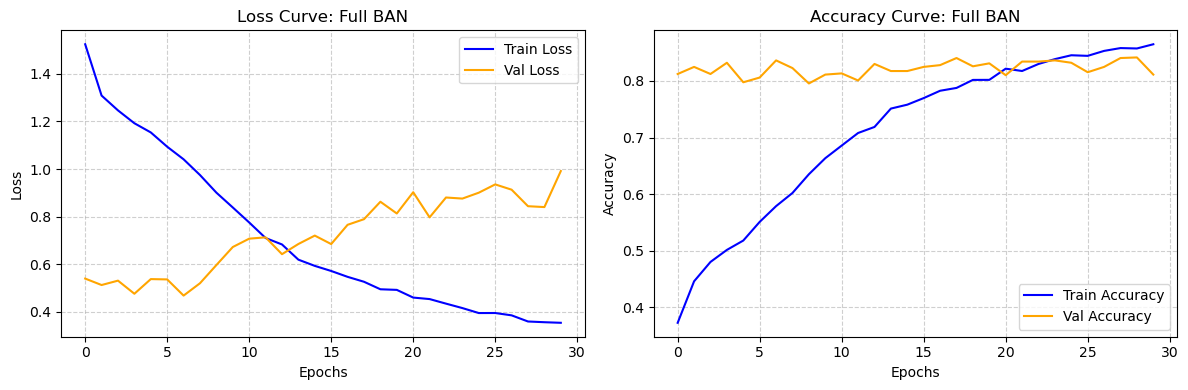


--- Evaluating ---
73/73 [==============================] - 1s 17ms/step - loss: 0.8278 - accuracy: 0.8364

Generating Predictions...
73/73 [==============================] - 3s 17ms/step

--- Full Classification Report for Full BAN ---
              precision    recall  f1-score   support

       anger     0.5611    0.4928    0.5247       345
     disgust     0.0962    0.0735    0.0833        68
        fear     0.1714    0.2400    0.2000        50
         joy     1.0000    1.0000    1.0000       402
     neutral     1.0000    0.9992    0.9996      1256
     sadness     0.4211    0.5000    0.4571       208

    accuracy                         0.8364      2329
   macro avg     0.5416    0.5509    0.5441      2329
weighted avg     0.8391    0.8364    0.8370      2329



In [3]:
# ==========================================
# 2. RUN THE EXPERIMENTS
# ==========================================

# Exp 1: The Full Enhanced Framework (Everything ON)
ablation_results['Full BAN (All Enhancements)'] = run_ablation_experiment(
    "Full BAN", use_aug=True, use_mask=True, use_attention=True
)

## Experiment II: w/o Data Augmentation


EXPERIMENT: No Augmentation
 - Augmentation: False
 - Sentiment Masking: True
 - Attention Fusion: True

--- Preparing Datasets (Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']) ---

--- Processing Training Set ---


Processing disgust: 100%|██████████| 271/271 [00:08<00:00, 32.76it/s]



--- Processing dev Set (Original Only) ---


Processing disgust: 100%|██████████| 22/22 [00:00<00:00, 35.21it/s]



--- Processing test Set (Original Only) ---


Processing disgust: 100%|██████████| 68/68 [00:02<00:00, 33.33it/s]


Training...
Epoch 1/30
275/275 [==============================] - 21s 44ms/step - loss: 1.1737 - accuracy: 0.6199 - val_loss: 0.4965 - val_accuracy: 0.8372
Epoch 2/30
275/275 [==============================] - 11s 40ms/step - loss: 1.0383 - accuracy: 0.6567 - val_loss: 0.4624 - val_accuracy: 0.8497
Epoch 3/30
275/275 [==============================] - 10s 37ms/step - loss: 1.0092 - accuracy: 0.6621 - val_loss: 0.4514 - val_accuracy: 0.8528
Epoch 4/30
275/275 [==============================] - 11s 39ms/step - loss: 0.9882 - accuracy: 0.6650 - val_loss: 0.4548 - val_accuracy: 0.8518
Epoch 5/30
275/275 [==============================] - 10s 35ms/step - loss: 0.9718 - accuracy: 0.6673 - val_loss: 0.4380 - val_accuracy: 0.8528
Epoch 6/30
275/275 [==============================] - 11s 39ms/step - loss: 0.9620 - accuracy: 0.6705 - val_loss: 0.4189 - val_accuracy: 0.8643
Epoch 7/30
275/275 [==============================] - 11s 40ms/step - loss: 0.9463 - accuracy: 0.6729 - val_loss: 0.4210 - v

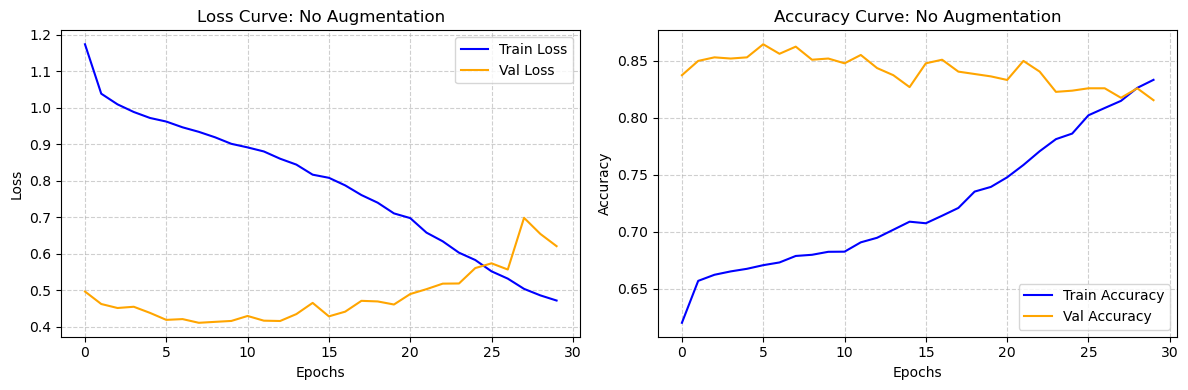


--- Evaluating ---
73/73 [==============================] - 3s 38ms/step - loss: 0.5529 - accuracy: 0.8424

Generating Predictions...
73/73 [==============================] - 14s 56ms/step

--- Full Classification Report for No Augmentation ---
              precision    recall  f1-score   support

       anger     0.5935    0.5797    0.5865       345
     disgust     0.1132    0.0882    0.0992        68
        fear     0.0879    0.1600    0.1135        50
         joy     1.0000    0.9975    0.9988       402
     neutral     1.0000    1.0000    1.0000      1256
     sadness     0.4764    0.4375    0.4561       208

    accuracy                         0.8424      2329
   macro avg     0.5452    0.5438    0.5423      2329
weighted avg     0.8475    0.8424    0.8446      2329



In [4]:
ablation_results['w/o Augmentation'] = run_ablation_experiment(
    "No Augmentation", use_aug=False, use_mask=True, use_attention=True
)

## Experiment III: w/o Sentiment Masking


EXPERIMENT: No Masking
 - Augmentation: True
 - Sentiment Masking: False
 - Attention Fusion: True

--- Preparing Datasets (Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']) ---

--- Processing Training Set ---
 -> Class 'neutral': 4709 original. Downsampling to 1700.


Processing neutral: 100%|██████████| 1700/1700 [01:45<00:00, 16.18it/s]


 -> Class 'joy': 1743 original. Downsampling to 1700.


Processing joy: 100%|██████████| 1700/1700 [01:47<00:00, 15.88it/s]


 -> Class 'sadness': 683 original. Expanding 3x to reach ~1700.


...


--- Processing dev Set (Original Only) ---


Processing disgust: 100%|██████████| 22/22 [00:01<00:00, 16.62it/s]



--- Processing test Set (Original Only) ---


Processing disgust: 100%|██████████| 68/68 [00:04<00:00, 15.58it/s]


Training...
Epoch 1/30
358/358 [==============================] - 59s 112ms/step - loss: 1.0659 - accuracy: 0.5611 - val_loss: 0.5281 - val_accuracy: 0.8215
Epoch 2/30
358/358 [==============================] - 31s 88ms/step - loss: 0.8660 - accuracy: 0.6226 - val_loss: 0.5216 - val_accuracy: 0.8194
Epoch 3/30
358/358 [==============================] - 31s 87ms/step - loss: 0.8095 - accuracy: 0.6577 - val_loss: 0.5548 - val_accuracy: 0.7965
Epoch 4/30
358/358 [==============================] - 26s 72ms/step - loss: 0.7601 - accuracy: 0.6803 - val_loss: 0.4996 - val_accuracy: 0.8267
Epoch 5/30
358/358 [==============================] - 26s 72ms/step - loss: 0.7012 - accuracy: 0.7138 - val_loss: 0.4958 - val_accuracy: 0.8278
Epoch 6/30
358/358 [==============================] - 25s 71ms/step - loss: 0.6381 - accuracy: 0.7405 - val_loss: 0.5399 - val_accuracy: 0.8132
Epoch 7/30
358/358 [==============================] - 26s 72ms/step - loss: 0.5569 - accuracy: 0.7808 - val_loss: 0.5619 - 

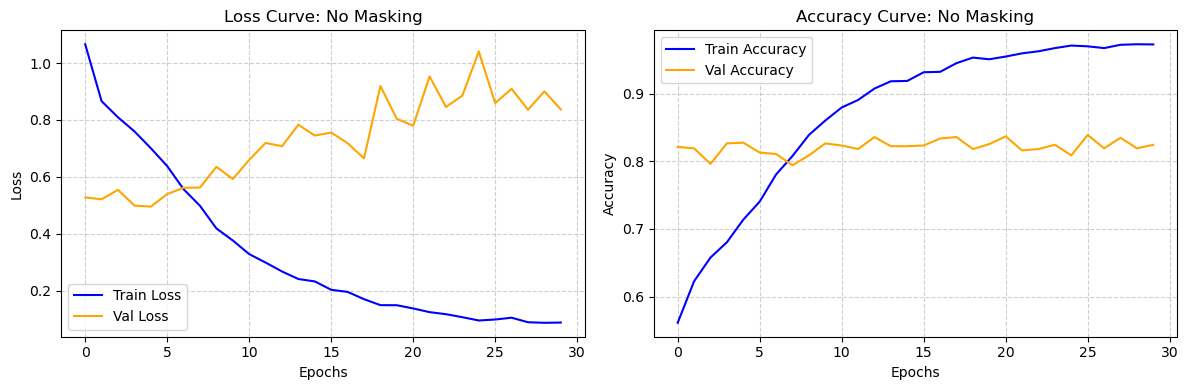


--- Evaluating ---
73/73 [==============================] - 2s 29ms/step - loss: 0.7902 - accuracy: 0.8454

Generating Predictions...
73/73 [==============================] - 5s 22ms/step

--- Full Classification Report for No Masking ---
              precision    recall  f1-score   support

       anger     0.6055    0.5739    0.5893       345
     disgust     0.1020    0.0735    0.0855        68
        fear     0.1648    0.3000    0.2128        50
         joy     1.0000    1.0000    1.0000       402
     neutral     1.0000    1.0000    1.0000      1256
     sadness     0.4559    0.4471    0.4515       208

    accuracy                         0.8454      2329
   macro avg     0.5547    0.5658    0.5565      2329
weighted avg     0.8488    0.8454    0.8466      2329



In [5]:
ablation_results['w/o Sentiment Masking'] = run_ablation_experiment(
    "No Masking", use_aug=True, use_mask=False, use_attention=True
)

## Experiment IV: w/o Attention


EXPERIMENT: No Attention
 - Augmentation: True
 - Sentiment Masking: True
 - Attention Fusion: False

--- Preparing Datasets (Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']) ---

--- Processing Training Set ---
 -> Class 'neutral': 4709 original. Downsampling to 1700.


Processing neutral: 100%|██████████| 1700/1700 [01:32<00:00, 18.28it/s]


 -> Class 'joy': 1743 original. Downsampling to 1700.


Processing joy: 100%|██████████| 1700/1700 [01:31<00:00, 18.52it/s]


 -> Class 'sadness': 683 original. Expanding 3x to reach ~1700.


...


--- Processing dev Set (Original Only) ---


Processing disgust: 100%|██████████| 22/22 [00:01<00:00, 18.38it/s]



--- Processing test Set (Original Only) ---


Processing disgust: 100%|██████████| 68/68 [00:03<00:00, 18.25it/s]


Training...
Epoch 1/30
358/358 [==============================] - 32s 66ms/step - loss: 1.6006 - accuracy: 0.3404 - val_loss: 0.5666 - val_accuracy: 0.7630
Epoch 2/30
358/358 [==============================] - 20s 55ms/step - loss: 1.3158 - accuracy: 0.4465 - val_loss: 0.5380 - val_accuracy: 0.7881
Epoch 3/30
358/358 [==============================] - 16s 45ms/step - loss: 1.2229 - accuracy: 0.4844 - val_loss: 0.5213 - val_accuracy: 0.7881
Epoch 4/30
358/358 [==============================] - 17s 47ms/step - loss: 1.1642 - accuracy: 0.5115 - val_loss: 0.5305 - val_accuracy: 0.7714
Epoch 5/30
358/358 [==============================] - 22s 61ms/step - loss: 1.1141 - accuracy: 0.5397 - val_loss: 0.5077 - val_accuracy: 0.7944
Epoch 6/30
358/358 [==============================] - 16s 46ms/step - loss: 1.0564 - accuracy: 0.5653 - val_loss: 0.5028 - val_accuracy: 0.7996
Epoch 7/30
358/358 [==============================] - 20s 57ms/step - loss: 1.0075 - accuracy: 0.5900 - val_loss: 0.4881 - v

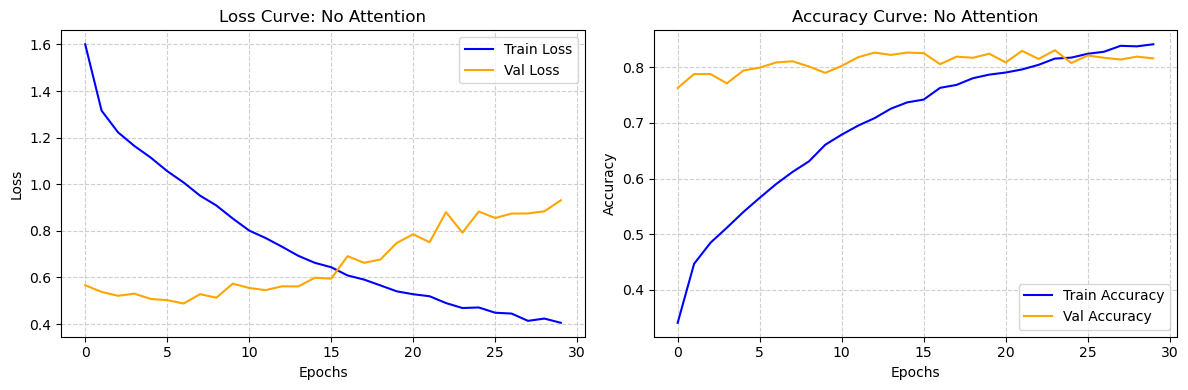


--- Evaluating ---
73/73 [==============================] - 1s 16ms/step - loss: 0.8025 - accuracy: 0.8313

Generating Predictions...
73/73 [==============================] - 5s 29ms/step

--- Full Classification Report for No Attention ---
              precision    recall  f1-score   support

       anger     0.5517    0.5101    0.5301       345
     disgust     0.0833    0.0735    0.0781        68
        fear     0.0806    0.1000    0.0893        50
         joy     1.0000    1.0000    1.0000       402
     neutral     1.0000    1.0000    1.0000      1256
     sadness     0.4000    0.4423    0.4201       208

    accuracy                         0.8313      2329
   macro avg     0.5193    0.5210    0.5196      2329
weighted avg     0.8335    0.8313    0.8321      2329



In [6]:
ablation_results['w/o Multi-Head Attention'] = run_ablation_experiment(
    "No Attention", use_aug=True, use_mask=True, use_attention=False
)

# Ablation Study

In [7]:
# ==========================================
# 3. DISPLAY FULL ABLATION TABLE
# ==========================================
print("\n" + "="*100)
print("FINAL ABLATION STUDY RESULTS (FULL METRICS)")
print("="*100)

df_results = pd.DataFrame(ablation_results).T

# Calculate the drop in accuracy and macro F1 from the Full BAN
baseline_acc = df_results.loc['Full BAN (All Enhancements)', 'Accuracy']
baseline_macro_f1 = df_results.loc['Full BAN (All Enhancements)', 'Macro F1']

df_results.insert(1, 'Acc Drop', baseline_acc - df_results['Accuracy'])
df_results.insert(5, 'Macro F1 Drop', baseline_macro_f1 - df_results['Macro F1'])

# Display the main metrics clearly
main_metrics = ['Accuracy', 'Acc Drop', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Macro F1 Drop']
print("\n--- Overall Performance ---")
display(df_results[main_metrics].round(4))

# Display class-specific F1 scores (Focus on the challenging classes)
f1_cols = [col for col in df_results.columns if col.endswith('F1') and 'Macro' not in col]
print("\n--- Class-Specific F1-Scores ---")
display(df_results[f1_cols].round(4))


FINAL ABLATION STUDY RESULTS (FULL METRICS)

--- Overall Performance ---


,Accuracy,Acc Drop,Macro Precision,Macro Recall,Macro F1,Macro F1 Drop
Full BAN (All Enhancements),0.8364,0.0000,0.5416,0.5509,0.5441,0.0000
w/o Augmentation,0.8424,-0.0060,0.5452,0.5438,0.5423,0.0018
w/o Sentiment Masking,0.8454,-0.0090,0.5547,0.5658,0.5565,-0.0124
w/o Multi-Head Attention,0.8313,0.0052,0.5193,0.5210,0.5196,0.0245



--- Class-Specific F1-Scores ---


,Anger F1,Disgust F1,Fear F1,Joy F1,Neutral F1,Sadness F1
Full BAN (All Enhancements),0.5247,0.0833,0.2000,1.0000,0.9996,0.4571
w/o Augmentation,0.5865,0.0992,0.1135,0.9988,1.0000,0.4561
w/o Sentiment Masking,0.5893,0.0855,0.2128,1.0000,1.0000,0.4515
w/o Multi-Head Attention,0.5301,0.0781,0.0893,1.0000,1.0000,0.4201


In [8]:
# ==========================================
# 3. DISPLAY HIGH-RESOLUTION ABLATION TABLES
# ==========================================
import pandas as pd
from IPython.display import display, HTML

print("\n" + "="*120)
print("FINAL ABLATION STUDY RESULTS (HIGH-RESOLUTION)")
print("="*120)

df_results = pd.DataFrame(ablation_results).T

# --- 1. Identify Baseline ---
baseline_name = 'Full BAN (All Enhancements)'
baseline = df_results.loc[baseline_name]

# --- 2. Calculate Comprehensive Drops (Absolute and Percentage) ---
# We calculate the Delta (Δ) and the Percentage Drop for main metrics
main_metrics = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']

for metric in main_metrics:
    # Absolute difference (Negative means a drop from baseline)
    df_results[f'Δ {metric}'] = df_results[metric] - baseline[metric]
    # Percentage drop relative to baseline
    # Formula: (Current - Baseline) / Baseline * 100 (Negative % means degradation)
    df_results[f'% Δ {metric}'] = ((df_results[metric] - baseline[metric]) / baseline[metric]) * 100

# Organize Columns for Table 1
overall_cols = []
for metric in main_metrics:
    overall_cols.extend([metric, f'Δ {metric}', f'% Δ {metric}'])

print("\n" + "="*120)
print("TABLE 1: OVERALL SYSTEM PERFORMANCE & DEGRADATION")
print("Shows the absolute and percentage impact of removing each enhancement.")
print("="*120)
display(df_results[overall_cols].round(4))

# --- 3. Class-Specific F1 Score Degradation ---
print("\n" + "="*120)
print("TABLE 2: CLASS-SPECIFIC F1-SCORE DEGRADATION MATRIX")
print("Highlights which specific emotions suffer most when enhancements are removed.")
print("="*120)

# Extract just the class F1 columns
f1_cols = [c for c in df_results.columns if c.endswith('F1') and 'Macro' not in c]
f1_df = df_results[f1_cols].copy()

# Calculate Absolute Drop for F1 scores
f1_display_cols = []
for col in f1_cols:
    delta_col_name = f'Δ {col}'
    f1_df[delta_col_name] = f1_df[col] - baseline[col]
    f1_display_cols.extend([col, delta_col_name])

display(f1_df[f1_display_cols].round(4))

# --- 4. Granular Deep Dive (P, R, F1 for ALL Classes) ---
print("\n" + "="*120)
print("TABLE 3: GRANULAR DEEP DIVE (PRECISION, RECALL, F1 PER CLASS)")
print("Detailed breakdown to analyze if an ablation hurts precision (false positives) or recall (missed detections).")
print("="*120)

# Extract all class metrics, avoiding the Macro and Delta columns
class_metrics = [c for c in df_results.columns if any(x in c for x in ['Precision', 'Recall', 'F1']) 
                 and 'Macro' not in c 
                 and 'Δ' not in c 
                 and '%' not in c]

# Optional: Sort columns alphabetically by Class Name for easier reading
class_metrics.sort() 
display(df_results[class_metrics].round(4))


FINAL ABLATION STUDY RESULTS (HIGH-RESOLUTION)

TABLE 1: OVERALL SYSTEM PERFORMANCE & DEGRADATION
Shows the absolute and percentage impact of removing each enhancement.


,Accuracy,Δ Accuracy,% Δ Accuracy,Macro Precision,Δ Macro Precision,% Δ Macro Precision,Macro Recall,Δ Macro Recall,% Δ Macro Recall,Macro F1,Δ Macro F1,% Δ Macro F1
Full BAN (All Enhancements),0.8364,0.0000,0.0000,0.5416,0.0000,0.0000,0.5509,0.0000,0.0000,0.5441,0.0000,0.0000
w/o Augmentation,0.8424,0.0060,0.7187,0.5452,0.0036,0.6567,0.5438,-0.0071,-1.2866,0.5423,-0.0018,-0.3282
w/o Sentiment Masking,0.8454,0.0090,1.0780,0.5547,0.0131,2.4178,0.5658,0.0148,2.6946,0.5565,0.0124,2.2730
w/o Multi-Head Attention,0.8313,-0.0052,-0.6160,0.5193,-0.0223,-4.1231,0.5210,-0.0299,-5.4305,0.5196,-0.0245,-4.5071



TABLE 2: CLASS-SPECIFIC F1-SCORE DEGRADATION MATRIX
Highlights which specific emotions suffer most when enhancements are removed.


,Anger F1,Δ Anger F1,Disgust F1,Δ Disgust F1,Fear F1,Δ Fear F1,Joy F1,Δ Joy F1,Neutral F1,Δ Neutral F1,Sadness F1,Δ Sadness F1
Full BAN (All Enhancements),0.5247,0.0000,0.0833,0.0000,0.2000,0.0000,1.0000,0.0000,0.9996,0.0000,0.4571,0.0000
w/o Augmentation,0.5865,0.0618,0.0992,0.0158,0.1135,-0.0865,0.9988,-0.0012,1.0000,0.0004,0.4561,-0.0010
w/o Sentiment Masking,0.5893,0.0646,0.0855,0.0021,0.2128,0.0128,1.0000,0.0000,1.0000,0.0004,0.4515,-0.0057
w/o Multi-Head Attention,0.5301,0.0054,0.0781,-0.0052,0.0893,-0.1107,1.0000,0.0000,1.0000,0.0004,0.4201,-0.0371



TABLE 3: GRANULAR DEEP DIVE (PRECISION, RECALL, F1 PER CLASS)
Detailed breakdown to analyze if an ablation hurts precision (false positives) or recall (missed detections).


,Anger F1,Anger Precision,Anger Recall,Disgust F1,Disgust Precision,Disgust Recall,Fear F1,Fear Precision,Fear Recall,Joy F1,Joy Precision,Joy Recall,Neutral F1,Neutral Precision,Neutral Recall,Sadness F1,Sadness Precision,Sadness Recall
Full BAN (All Enhancements),0.5247,0.5611,0.4928,0.0833,0.0962,0.0735,0.2000,0.1714,0.24,1.0000,1.0,1.0000,0.9996,1.0,0.9992,0.4571,0.4211,0.5000
w/o Augmentation,0.5865,0.5935,0.5797,0.0992,0.1132,0.0882,0.1135,0.0879,0.16,0.9988,1.0,0.9975,1.0000,1.0,1.0000,0.4561,0.4764,0.4375
w/o Sentiment Masking,0.5893,0.6055,0.5739,0.0855,0.1020,0.0735,0.2128,0.1648,0.30,1.0000,1.0,1.0000,1.0000,1.0,1.0000,0.4515,0.4559,0.4471
w/o Multi-Head Attention,0.5301,0.5517,0.5101,0.0781,0.0833,0.0735,0.0893,0.0806,0.10,1.0000,1.0,1.0000,1.0000,1.0,1.0000,0.4201,0.4000,0.4423
